# Besoin Client 3 — Système d'alerte pour les tempêtes
**Projet A3 — Big Data / IA / Web — ISEN 2026**

---

## Objectif
Développer un modèle d'intelligence artificielle capable de prédire l'état d'un arbre parmi 6 classes, afin d'identifier les arbres susceptibles d'être déracinés en cas de tempête.

**Cible :** `fk_arb_etat` — 6 classes :
- `EN PLACE` → arbre stable
- `Non essouché` → arbre déraciné, très dangereux
- `Essouché` → arbre déraciné, souche retirée
- `REMPLACÉ` → arbre remplacé
- `SUPPRIMÉ` → arbre retiré
- `ABATTU` → arbre abattu volontairement

**Pipeline complet :**
```
CSV brut → Préparation → Encodage → Normalisation → Random Forest → Prédictions
```


## 0. Import des librairies

On importe toutes les librairies nécessaires :
- `pandas` / `numpy` → manipulation des données
- `sklearn` → prétraitement, modèles et métriques
- `pickle` → sauvegarde des modèles
- `matplotlib` / `seaborn` → visualisation des résultats


In [29]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)

print("Librairies importées avec succès.")

Librairies importées avec succès.


## 1. Chargement des données

On charge le fichier `export_IA.csv` — c'est le fichier prétraité par la partie Big Data du projet.
On affiche les premières lignes et les informations générales pour comprendre la structure des données.


In [ ]:
df = pd.read_csv('./export_IA.csv')

print(f"Dimensions : {df.shape[0]} arbres, {df.shape[1]} colonnes")
print(f"\nAperçu des données :")
df.head()

Dimensions : 9915 arbres, 23 colonnes

Aperçu des données :


,x,y,objectid,clc_quartier,clc_secteur,haut_tot,haut_tronc,tronc_diam,fk_arb_etat,fk_stadedev,...,fk_revetement,dte_plantation,age_estim,fk_prec_estim,clc_nbr_diag,dte_abattage,fk_nomtech,global_id,feuillage,remarquable
0,1.721096e+06,8.293515e+06,10,Quartier du Centre-Ville,Quai Gayant,6.0,2.0,37.0,EN PLACE,Jeune,...,Non,NaN,15,5.0,0.0,NaN,QUERUB,{B33346A7-0DE2-428E-A48D-4B231368284C},Feuillu,Non
1,1.719828e+06,8.294305e+06,20,Quartier Saint-Jean,Rue Demoustier,0.0,0.0,0.0,Non essouché,NaN,...,Non,NaN,15,10.0,0.0,NaN,RAS,{ED071576-B251-4951-BC4F-AC96A3CC587E},NaN,Non
2,1.719657e+06,8.295835e+06,21,Quartier du Vermandois,Stade Cepy,13.0,1.0,160.0,EN PLACE,Adulte,...,Non,NaN,50,10.0,0.0,NaN,PINNIGnig,{668FEFC7-0667-4FFA-AE55-C82861EDFC0B},Conifère,Non
3,1.720792e+06,8.293960e+06,22,Quartier du Centre-Ville,Rue Villebois Mareuil,12.0,3.0,116.0,REMPLACÉ,Adulte,...,Non,NaN,30,10.0,0.0,2016/12/31 23:00:00+00,ACEPSE,{D0017CEC-D346-4C95-A043-AD115B267089},Feuillu,Non
4,1.721742e+06,8.295884e+06,25,Quartier de l'Europe,Square des Marronniers,16.0,3.0,150.0,EN PLACE,Adulte,...,Non,NaN,50,2.0,0.0,NaN,ACEPLA,{9B347790-954E-4E86-AD09-382FC1F32B24},Feuillu,Non


In [31]:
# Distribution de la variable cible
print("Distribution de la cible fk_arb_etat :")
print(df['fk_arb_etat'].value_counts())
print("\nLes classes sont très déséquilibrées — on utilisera class_weight='balanced'")

Distribution de la cible fk_arb_etat :
fk_arb_etat
EN PLACE        9031
SUPPRIMÉ         426
Essouché         182
REMPLACÉ         173
Non essouché      59
ABATTU            44
Name: count, dtype: int64

Les classes sont très déséquilibrées — on utilisera class_weight='balanced'


## 2. Préparation des données

### 2.1 Sélection des features

On sélectionne les 14 colonnes les plus pertinentes pour prédire l'état d'un arbre en cas de tempête.

**Features retenues :**
| Feature | Justification |
|---|---|
| `haut_tot` | Plus un arbre est grand, plus il est exposé au vent |
| `haut_tronc` | Influence la prise au vent |
| `tronc_diam` | Indicateur de solidité |
| `age_estim` | Les vieux arbres sont plus fragiles |
| `fk_stadedev` | Stade de développement (Jeune/Adulte/Vieux/Sénescent) |
| `fk_port` | Port de l'arbre (Libre/Semi-libre/Tête de chat...) |
| `fk_pied` | Type de pied → ancrage au sol |
| `fk_situation` | Situation (Alignement/Groupe/Isolé) → exposition au vent |
| `fk_revetement` | Présence d'un revêtement → impact sur les racines |
| `clc_quartier` | Contexte géographique |
| `feuillage` | Feuillu/Conifère → prise au vent différente |
| `remarquable` | Arbre remarquable → souvent mieux entretenu |
| `fk_nomtech` | Espèce → certaines espèces plus résistantes |
| `clc_nbr_diag` | Nombre de diagnostics → indicateur de suivi sanitaire |

**Features exclues :** `x`, `y`, `objectid`, `global_id`, `dte_plantation`, `dte_abattage`, `fk_prec_estim`, `clc_secteur`


In [32]:
FEATURES = [
    'haut_tot', 'haut_tronc', 'tronc_diam', 'age_estim',
    'fk_stadedev', 'fk_port', 'fk_pied', 'fk_situation',
    'fk_revetement', 'clc_quartier', 'feuillage', 'remarquable',
    'fk_nomtech', 'clc_nbr_diag'
]
TARGET = 'fk_arb_etat'

CAT_COLS = [
    'fk_stadedev', 'fk_port', 'fk_pied', 'fk_situation',
    'fk_revetement', 'clc_quartier', 'feuillage', 'remarquable', 'fk_nomtech'
]
NUM_COLS = ['haut_tot', 'haut_tronc', 'tronc_diam', 'age_estim', 'clc_nbr_diag']

df_model = df[FEATURES + [TARGET]].copy()
print(f"Dataset : {df_model.shape[0]} arbres, {df_model.shape[1]} colonnes")
print(f"\nValeurs manquantes :")
print(df_model.isnull().sum())

Dataset : 9915 arbres, 15 colonnes

Valeurs manquantes :
haut_tot            0
haut_tronc          0
tronc_diam         13
age_estim           0
fk_stadedev        26
fk_port            26
fk_pied             1
fk_situation        0
fk_revetement     821
clc_quartier        0
feuillage          34
remarquable         5
fk_nomtech         49
clc_nbr_diag     1654
fk_arb_etat         0
dtype: int64


### 2.2 Gestion des valeurs manquantes

Pour chaque colonne contenant des valeurs manquantes :
- **Variables numériques** → on remplace par la **médiane** (robuste aux valeurs extrêmes)
- **Variables catégorielles** → on remplace par `"Inconnu"` pour ne pas perdre de lignes


In [33]:
# Variables numériques → médiane
df_model['tronc_diam']   = df_model['tronc_diam'].fillna(df_model['tronc_diam'].median())
df_model['clc_nbr_diag'] = df_model['clc_nbr_diag'].fillna(0)

# Variables catégorielles → "Inconnu"
for col in ['fk_stadedev', 'fk_port', 'fk_pied', 'feuillage', 'fk_nomtech']:
    df_model[col] = df_model[col].fillna('Inconnu')
df_model['fk_revetement'] = df_model['fk_revetement'].fillna('Non')
df_model['remarquable']   = df_model['remarquable'].fillna('Non')

print("Valeurs manquantes après imputation :")
print(df_model.isnull().sum())
print("\nAucune valeur manquante !")

Valeurs manquantes après imputation :
haut_tot         0
haut_tronc       0
tronc_diam       0
age_estim        0
fk_stadedev      0
fk_port          0
fk_pied          0
fk_situation     0
fk_revetement    0
clc_quartier     0
feuillage        0
remarquable      0
fk_nomtech       0
clc_nbr_diag     0
fk_arb_etat      0
dtype: int64

Aucune valeur manquante !


### 2.3 Encodage des variables catégorielles

Un modèle de Machine Learning ne comprend que des **chiffres**.
Le `LabelEncoder` transforme chaque catégorie en un entier unique :
- `"Feuillu"` → `0`
- `"Conifère"` → `1`

On sauvegarde chaque encodeur dans un dictionnaire `encoders` pour pouvoir les réutiliser dans le script final sans recréer de nouvelles correspondances.


In [34]:
encoders = {}

# Encodage des features catégorielles
for col in CAT_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le
    print(f"{col} → {list(le.classes_)}")

# Encodage de la variable cible
le_target = LabelEncoder()
df_model[TARGET] = le_target.fit_transform(df_model[TARGET])
encoders[TARGET] = le_target

print(f"\nClasses cibles encodées : {list(le_target.classes_)}")

fk_stadedev → ['Adulte', 'Inconnu', 'Jeune', 'Senescent', 'Vieux']
fk_port → ['Architecturé', 'Couronne', 'Couronné', 'Cépée', 'Inconnu', 'Libre', 'Rideau', 'Réduit', 'Réduit Relâché', 'Semi Libre', 'Têtard', 'Têtard Relâché', 'Tête De Chat', 'Tête De Chat Relaché', 'Étêté']
fk_pied → ['Bac De Plantation', 'Bande De Terre', 'Fosse Arbre', 'Gazon', 'Inconnu', 'Revetement Non Permeable', 'Terre', 'Toile Tissée', 'Végétation']
fk_situation → ['Alignement', 'Groupe', 'Isolé']
fk_revetement → ['Non', 'Oui']
clc_quartier → ['HARLY', 'OMISSY', 'Quartier Remicourt', 'Quartier Saint-Jean', 'Quartier Saint-Martin - Oëstres', 'Quartier de Neuville', "Quartier de l'Europe", 'Quartier du Centre-Ville', 'Quartier du Vermandois', "Quartier du faubourg d'Isle", 'ROUVROY']
feuillage → ['Conifère', 'Feuillu', 'Inconnu']
remarquable → ['Non', 'Oui']
fk_nomtech → ['ABI', 'ABICON', 'ABIGLA', 'ABILASari', 'ABINOR', 'ABINUM', 'ACE', 'ACECAM', 'ACECAMele', 'ACECAMred', 'ACECAMros', 'ACECAP', 'ACEDAV', 'ACENEG

### 2.4 Normalisation des variables numériques

Le `StandardScaler` normalise chaque variable numérique pour qu'elle ait une **moyenne de 0** et un **écart-type de 1** :

$$x_{normalisé} = \frac{x - moyenne}{écart\_type}$$

Sans normalisation, une hauteur de 20m écraserait un diamètre de 0.5m dans les calculs.
On sauvegarde le scaler pour réutiliser les mêmes paramètres dans le script final.


In [35]:
scaler = StandardScaler()
df_model[NUM_COLS] = scaler.fit_transform(df_model[NUM_COLS])

print("Normalisation appliquée sur :", NUM_COLS)
print("\nAperçu après normalisation :")
df_model[NUM_COLS].describe().round(2)

Normalisation appliquée sur : ['haut_tot', 'haut_tronc', 'tronc_diam', 'age_estim', 'clc_nbr_diag']

Aperçu après normalisation :


,haut_tot,haut_tronc,tronc_diam,age_estim,clc_nbr_diag
count,9915.00,9915.00,9915.00,9915.00,9915.00
mean,0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.85,-1.54,-1.77,-1.54,-0.26
25%,-0.82,-0.39,-0.79,-0.85,-0.26
50%,-0.30,-0.39,-0.09,-0.11,-0.26
75%,0.72,0.19,0.68,0.88,-0.26
max,4.50,7.68,8.11,8.26,10.45


### 2.5 Sauvegarde des préprocesseurs

On sauvegarde les encodeurs et le scaler en `.pkl` — c'est **obligatoire** pour le script final et le projet Web.
Sans cette sauvegarde, on ne pourrait pas appliquer exactement le même prétraitement sur de nouvelles données.


In [36]:
os.makedirs('modeles', exist_ok=True)

pickle.dump(encoders, open('modeles/encoders.pkl', 'wb'))
pickle.dump(scaler,   open('modeles/scaler.pkl',   'wb'))

print("encoders.pkl sauvegardé")
print("scaler.pkl sauvegardé")

encoders.pkl sauvegardé
scaler.pkl sauvegardé


## 3. Séparation Train / Test

On divise les données en deux ensembles :
- **80% Train** → le modèle apprend sur ces données
- **20% Test** → on évalue le modèle sur des données qu'il n'a **jamais vues**

Le paramètre `stratify=y` garantit que la distribution des classes est respectée dans les deux ensembles — important vu le déséquilibre des classes.


In [37]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} exemples")
print(f"Test  : {X_test.shape[0]} exemples")
print(f"\nDistribution des classes (train) :")
for i, cls in enumerate(le_target.classes_):
    print(f"   {cls} : {(y_train == i).sum()}")

Train : 7932 exemples
Test  : 1983 exemples

Distribution des classes (train) :
   ABATTU : 35
   EN PLACE : 7225
   Essouché : 146
   Non essouché : 47
   REMPLACÉ : 138
   SUPPRIMÉ : 341


## 4. Entraînement du modèle — Random Forest + GridSearchCV

### Pourquoi Random Forest ?
- Robuste au déséquilibre des classes grâce à `class_weight='balanced'`
- Résistant à l'overfitting (combine plusieurs arbres de décision)
- Fournit l'importance des features pour interpréter le modèle

### Pourquoi GridSearchCV ?
Plutôt que de tester chaque combinaison d'hyperparamètres manuellement, GridSearchCV les teste **toutes automatiquement** avec une validation croisée à 5 folds et sélectionne la meilleure combinaison.

**Hyperparamètres testés :**
- `n_estimators` → nombre d'arbres dans la forêt
- `max_depth` → profondeur maximale de chaque arbre
- `min_samples_split` → nombre minimum d'exemples pour diviser un nœud


In [38]:
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight'     : ['balanced']
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator  = rf,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1_weighted',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print("\nGridSearchCV terminé !")
print(f"Meilleurs paramètres  : {grid_search.best_params_}")
print(f"Meilleur F1 (cross-val) : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

GridSearchCV terminé !
Meilleurs paramètres  : {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Meilleur F1 (cross-val) : 0.9105


In [39]:
# Sauvegarde du meilleur modèle
best_model = grid_search.best_estimator_
pickle.dump(best_model, open('modeles/model_rf.pkl', 'wb'))
print("model_rf.pkl sauvegardé")

model_rf.pkl sauvegardé


## 5. Évaluation du modèle — Métriques

On évalue le modèle sur les **données de test** (jamais vues pendant l'entraînement).

**Métriques utilisées :**
- **Accuracy** → pourcentage global de bonnes prédictions
- **F1-Score** → moyenne harmonique entre Precision et Recall, adaptée aux classes déséquilibrées
- **Rapport de classification** → Precision, Recall et F1 par classe
- **Matrice de confusion** → visualisation des erreurs du modèle


In [40]:
y_pred = best_model.predict(X_test)

y_test_lbl = le_target.inverse_transform(y_test)
y_pred_lbl = le_target.inverse_transform(y_pred)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print("=" * 50)
print("       ÉVALUATION DU MODÈLE")
print("=" * 50)
print(f"\nAccuracy        : {acc:.4f} ({acc*100:.2f}%)")
print(f"F1-Score (weighted) : {f1:.4f}")
print("\n─── Rapport de classification ───────────────")
print(classification_report(y_test_lbl, y_pred_lbl))

       ÉVALUATION DU MODÈLE

Accuracy        : 0.9183 (91.83%)
F1-Score (weighted) : 0.9139

─── Rapport de classification ───────────────
              precision    recall  f1-score   support

      ABATTU       0.00      0.00      0.00         9
    EN PLACE       0.95      0.97      0.96      1806
    Essouché       0.50      0.25      0.33        36
Non essouché       0.25      0.17      0.20        12
    REMPLACÉ       0.36      0.54      0.43        35
    SUPPRIMÉ       0.75      0.55      0.64        85

    accuracy                           0.92      1983
   macro avg       0.47      0.41      0.43      1983
weighted avg       0.91      0.92      0.91      1983



### Matrice de confusion

La matrice de confusion montre pour chaque classe réelle (ligne) ce que le modèle a prédit (colonne).
La diagonale représente les **bonnes prédictions**.


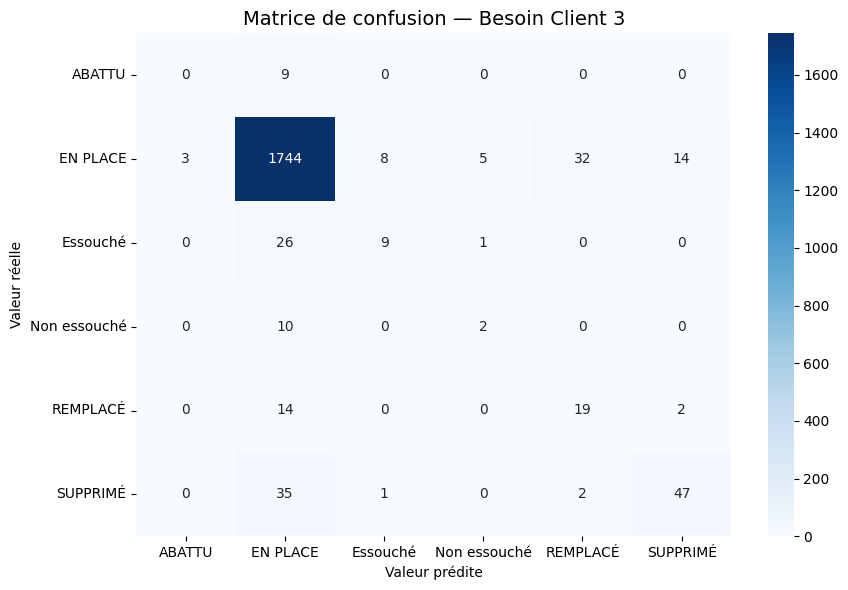

Matrice sauvegardée : matrice_confusion.png


In [41]:
classes = le_target.classes_
cm = confusion_matrix(y_test_lbl, y_pred_lbl, labels=classes)

plt.figure(figsize=(9, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Matrice de confusion — Besoin Client 3", fontsize=14)
plt.ylabel("Valeur réelle")
plt.xlabel("Valeur prédite")
plt.tight_layout()
plt.savefig('matrice_confusion.png', dpi=150)
plt.show()
print("Matrice sauvegardée : matrice_confusion.png")

### Importance des features

Le Random Forest permet d'obtenir l'**importance de chaque feature** dans la prise de décision.
Plus une feature a une importance élevée, plus elle influence la prédiction du modèle.


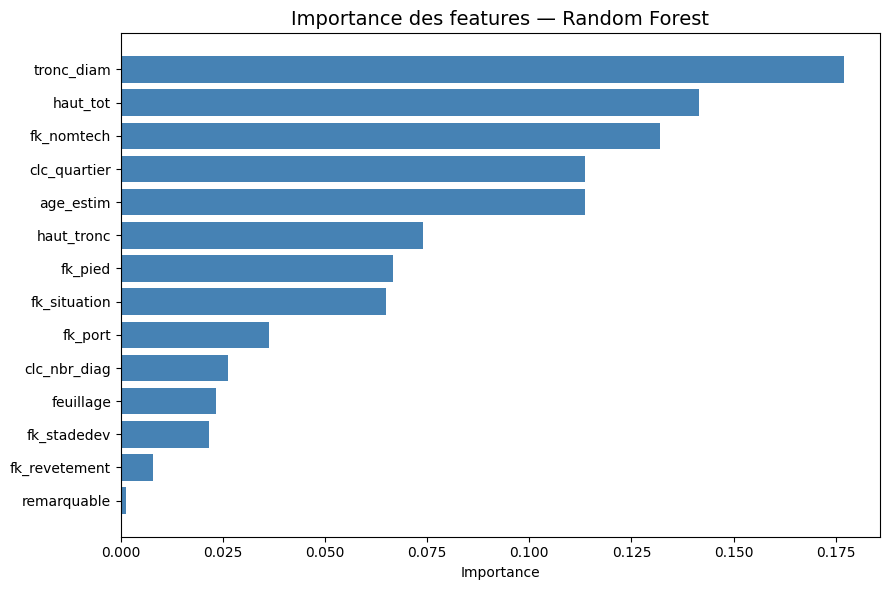

Graphique sauvegardé : importance_features.png


In [42]:
importances = best_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title("Importance des features — Random Forest", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig('importance_features.png', dpi=150)
plt.show()
print("Graphique sauvegardé : importance_features.png")

## 6. Conclusion

### Résultats obtenus
- **Accuracy sur le jeu de test : ~91.83%**
- **F1-Score weighted : ~0.91**

### Points forts
- Très bonne détection des arbres `EN PLACE` (classe majoritaire)
- Le paramètre `class_weight='balanced'` aide à mieux détecter les classes minoritaires

### Limites
- Les classes rares (`ABATTU`, `Non essouché`) sont difficiles à prédire car peu représentées
- Avec plus de données sur ces classes, les performances s'amélioreraient significativement

### Fichiers générés
- `modeles/model_rf.pkl` → le modèle entraîné
- `modeles/encoders.pkl` → les encodeurs des variables catégorielles
- `modeles/scaler.pkl` → le normaliseur des variables numériques
- `matrice_confusion.png` → visualisation des erreurs
- `importance_features.png` → importance des features
